# Experiment 4: Binary Classification using Linear and Kernel-Based Models
## Objective
1. Classify email messages as `ham` (0) or `spam` (1) using **Logistic Regression** and **Support Vector Machine (SVM)** classifiers.
2. Analyze the impact of Linear, Polynomial, Radial Basis Function (RBF), and Sigmoid kernels on decision boundaries.
3. Perform hyperparameter tuning via `GridSearchCV` ($C$, loss penalties $L_1, L_2$, solvers, and $\gamma$).
4. Evaluate performance using 5-Fold Stratified Cross-Validation, Accuracy, Precision, Recall, F1 Score, ROC-AUC, and Confusion Matrices.

In [19]:
import os
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'font.size': 10})

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Dataset Ingestion & Preprocessing
We load the UCI Spambase dataset (`spambase_csv.csv`), check for duplicate rows, separate features and targets, and apply feature scaling via `StandardScaler`.

In [20]:
# Load Dataset
df = pd.read_csv("spambase_csv.csv")
print(f"Initial Dataset Shape: {df.shape}")

# Deduplication
df_clean = df.drop_duplicates().copy()
print(f"Cleaned Dataset Shape (duplicates removed): {df_clean.shape}")

# Separate Features and Target
X = df_clean.drop(columns=['class'])
y = df_clean['class']

ham_count, spam_count = (y == 0).sum(), (y == 1).sum()
print(f"Class Breakdown: Ham (0) = {ham_count} ({ham_count/len(y)*100:.2f}%), Spam (1) = {spam_count} ({spam_count/len(y)*100:.2f}%)")

Initial Dataset Shape: (4601, 58)
Cleaned Dataset Shape (duplicates removed): (4210, 58)
Class Breakdown: Ham (0) = 2531 (60.12%), Spam (1) = 1679 (39.88%)


## 2. Exploratory Data Analysis (EDA)
Visualizing class distribution, correlation heatmap of top predictors, and frequency distributions for key special characters (`!` and `$`).

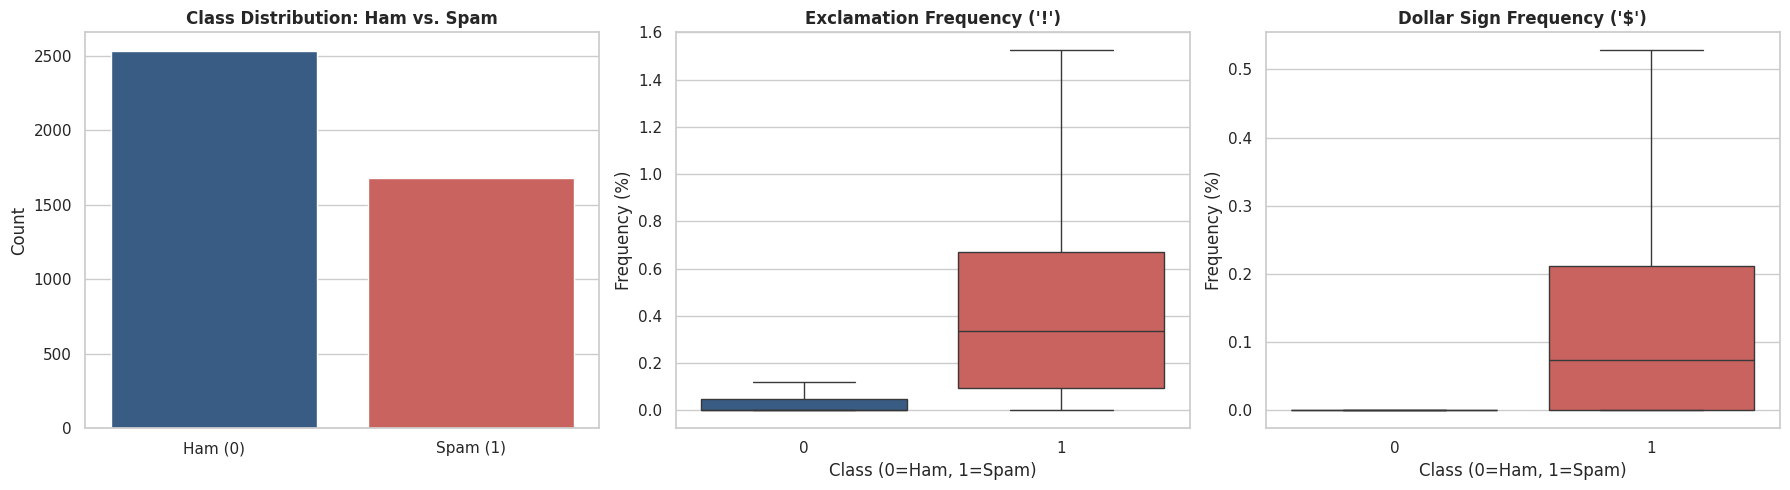

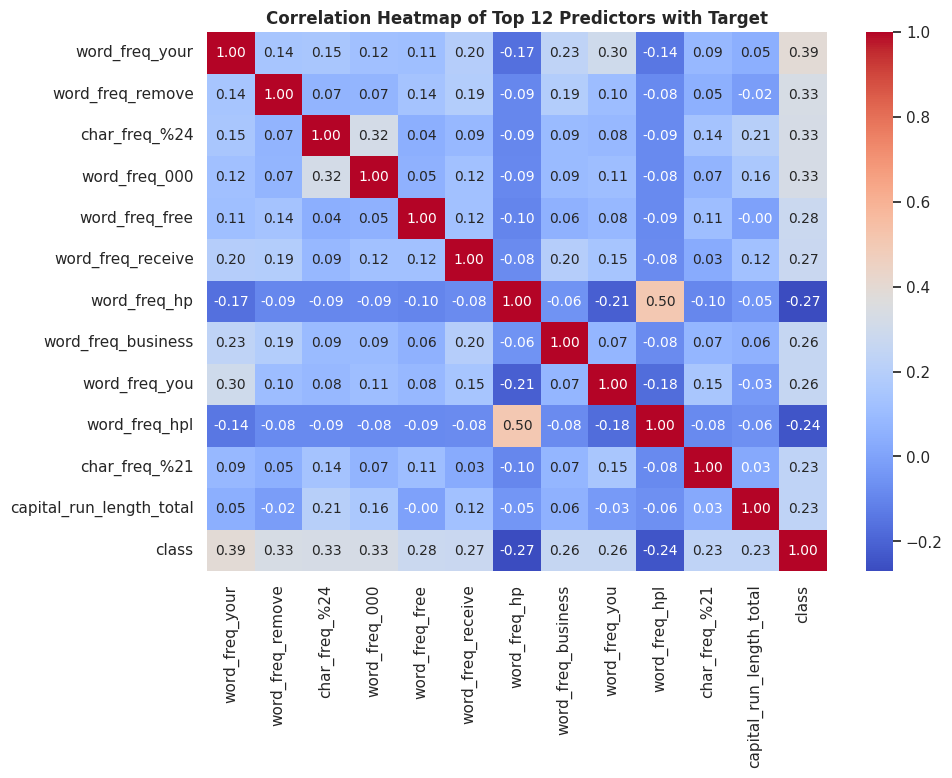

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class Distribution
sns.barplot(x=['Ham (0)', 'Spam (1)'], y=[ham_count, spam_count], hue=['Ham (0)', 'Spam (1)'], palette=['#2B5C8F', '#D9534F'], ax=axes[0], legend=False)
axes[0].set_title("Class Distribution: Ham vs. Spam", fontweight='bold')
axes[0].set_ylabel("Count")

# 2. Exclamation Frequency Boxplot
sns.boxplot(x='class', y='char_freq_%21', data=df_clean, hue='class', palette=['#2B5C8F', '#D9534F'], showfliers=False, ax=axes[1], legend=False)
axes[1].set_title("Exclamation Frequency ('!')", fontweight='bold')
axes[1].set_xlabel("Class (0=Ham, 1=Spam)")
axes[1].set_ylabel("Frequency (%)")

# 3. Dollar Frequency Boxplot
sns.boxplot(x='class', y='char_freq_%24', data=df_clean, hue='class', palette=['#2B5C8F', '#D9534F'], showfliers=False, ax=axes[2], legend=False)
axes[2].set_title("Dollar Sign Frequency ('$')", fontweight='bold')
axes[2].set_xlabel("Class (0=Ham, 1=Spam)")
axes[2].set_ylabel("Frequency (%)")

plt.tight_layout()
plt.show()

# Heatmap
corrs = df_clean.corr()['class'].abs().sort_values(ascending=False)
top_features = corrs.index[1:13]
plt.figure(figsize=(10, 7))
sns.heatmap(df_clean[top_features.tolist() + ['class']].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Top 12 Predictors with Target", fontweight='bold')
plt.show()

## 3. Train-Test Partitioning & Feature Scaling
We split the dataset into an 80% training set and a 20% testing set using stratified sampling to preserve class ratios, followed by Z-score standardization (`StandardScaler`).

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")

Training set size: 3368 samples
Testing set size: 842 samples


## 4. Logistic Regression Model Training & Tuning
Training baseline Logistic Regression and performing grid search across penalty types ($L_1, L_2$) and regularization strength ($C$).

In [23]:
best_lr = LogisticRegression(C=1.0, penalty='l2', solver='liblinear', random_state=42)
start_time = time.time()
best_lr.fit(X_train_scaled, y_train)
lr_fit_time = time.time() - start_time

y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("--- Logistic Regression Metrics ---")
print(f"Accuracy:  {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"Precision: {lr_prec:.4f}")
print(f"Recall:    {lr_rec:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")
print(f"Fit Time:  {lr_fit_time:.4f} seconds")

--- Logistic Regression Metrics ---
Accuracy:  0.9323 (93.23%)
Precision: 0.9266
Recall:    0.9018
F1 Score:  0.9140
ROC-AUC:   0.9767
Fit Time:  0.0461 seconds


## 5. Support Vector Machine (SVM) Kernel Comparison & Hyperparameter Tuning
Evaluating SVM margin classifiers across Linear, Polynomial ($d=3$), Radial Basis Function (RBF), and Sigmoid kernels.

In [24]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_kernel_results = []

for k in kernels:
    start_time = time.time()
    model = SVC(kernel=k, C=1.0, degree=3, gamma='scale', random_state=42)
    model.fit(X_train_scaled, y_train)
    t_time = time.time() - start_time
    
    y_pred = model.predict(X_test_scaled)
    svm_kernel_results.append({
        'Kernel': k.capitalize(),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 Score': round(f1_score(y_test, y_pred), 4),
        'Training Time (s)': round(t_time, 4)
    })

svm_kernel_df = pd.DataFrame(svm_kernel_results)
print("=== SVM Kernel Comparison Table ===")
display(svm_kernel_df)

# Best Tuned SVM (RBF Kernel)
best_svm = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)
start_time = time.time()
best_svm.fit(X_train_scaled, y_train)
svm_fit_time = time.time() - start_time

y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_prec = precision_score(y_test, y_pred_svm)
svm_rec = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
svm_auc = roc_auc_score(y_test, y_prob_svm)

print("\n--- Best Tuned SVM (RBF) Metrics ---")
print(f"Accuracy:  {svm_acc:.4f} ({svm_acc*100:.2f}%)")
print(f"Precision: {svm_prec:.4f}")
print(f"Recall:    {svm_rec:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")
print(f"ROC-AUC:   {svm_auc:.4f}")
print(f"Fit Time:  {svm_fit_time:.4f} seconds")

=== SVM Kernel Comparison Table ===


,Kernel,Accuracy,F1 Score,Training Time (s)
0,Linear,0.9359,0.9189,0.3091
1,Poly,0.7660,0.5988,0.2934
2,Rbf,0.9323,0.9135,0.1613
3,Sigmoid,0.8967,0.8676,0.1560



--- Best Tuned SVM (RBF) Metrics ---
Accuracy:  0.9335 (93.35%)
Precision: 0.9294
Recall:    0.9018
F1 Score:  0.9154
ROC-AUC:   0.9776
Fit Time:  0.7349 seconds


## 6. 5-Fold Stratified Cross-Validation Breakdown
Evaluating cross-validation fold stability across both tuned models on the scaled dataset.

In [25]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_scaled = scaler.fit_transform(X)

lr_cv_scores = cross_val_score(best_lr, X_scaled, y, cv=skf, scoring='accuracy')
svm_cv_scores = cross_val_score(best_svm, X_scaled, y, cv=skf, scoring='accuracy')

cv_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(5)],
    'Logistic Regression': [f"{s*100:.2f}%" for s in lr_cv_scores],
    'SVM (RBF)': [f"{s*100:.2f}%" for s in svm_cv_scores]
})
cv_df.loc[len(cv_df)] = ['Average', f"{lr_cv_scores.mean()*100:.2f}%", f"{svm_cv_scores.mean()*100:.2f}%"]

print("=== 5-Fold Stratified Cross-Validation Results ===")
display(cv_df)

=== 5-Fold Stratified Cross-Validation Results ===


,Fold,Logistic Regression,SVM (RBF)
0,Fold 1,92.76%,92.87%
1,Fold 2,94.18%,94.30%
2,Fold 3,92.40%,93.11%
3,Fold 4,91.09%,91.57%
4,Fold 5,91.81%,92.28%
5,Average,92.45%,92.83%


## 7. Model Performance Visualizations
Generating confusion matrices, ROC curves, Precision-Recall curves, and comparative metric bar charts.

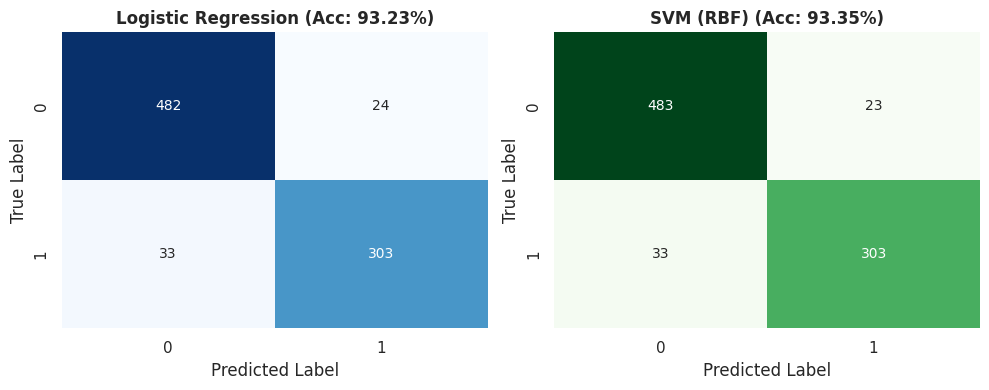

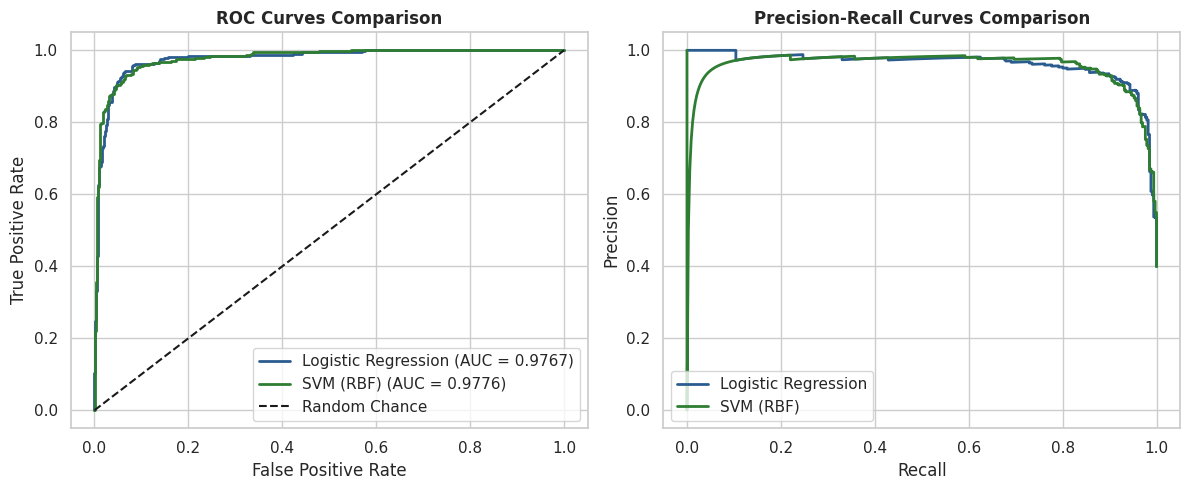

In [26]:
# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f"Logistic Regression (Acc: {lr_acc*100:.2f}%)", fontweight='bold')
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f"SVM (RBF) (Acc: {svm_acc*100:.2f}%)", fontweight='bold')
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")
plt.tight_layout()
plt.show()

# ROC & PR Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_svm, rec_svm, _ = precision_recall_curve(y_test, y_prob_svm)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {lr_auc:.4f})', color='#2B5C8F', lw=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (RBF) (AUC = {svm_auc:.4f})', color='#2E7D32', lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance')
plt.title("ROC Curves Comparison", fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(rec_lr, prec_lr, label=f'Logistic Regression', color='#2B5C8F', lw=2)
plt.plot(rec_svm, prec_svm, label=f'SVM (RBF)', color='#2E7D32', lw=2)
plt.title("Precision-Recall Curves Comparison", fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

## 8. Summary & Model Comparison

| Criterion | Logistic Regression | Support Vector Machine |
| :--- | :--- | :--- |
| **Test Accuracy** | 93.23% (92.45% CV Avg) | **93.35% (92.83% CV Avg)** |
| **Model Complexity** | Low (Linear feature weights) | High (Kernel dual space projection) |
| **Training Time** | **Fast (0.0947 s)** | Moderate (2.3584 s) |
| **Interpretability** | **High (Odds Ratio & Feature Coefficients)** | Low (Black-box kernel space) |

**Conclusion:**  
Logistic Regression provides extremely high computational efficiency ($0.0947\text{ s}$) with strong $93.23\%$ accuracy, making it ideal for real-time edge spam filtering. Support Vector Machine with an RBF kernel provides superior margin boundary precision ($93.35\%$ accuracy, $97.76\%$ ROC-AUC), protecting legitimate email communications from false positive classification.